In [ ]:
!pip install openai tiktoken koreanize-matplotlib

Colab Secrets에서 API 키 로드 완료
API 키 확인: sk-...WSEA

  블록 1. 역할 부여 유무 비교

[역할 없음]
질문: 딥러닝 기반 자연어처리 모델의 과적합 문제를 설명해줘
답변:
딥러닝 기반 자연어처리(NLP) 모델에서 과적합(overfitting)은 **훈련 데이터에는 성능이 매우 좋지만, 새로운 데이터(검증/테스트)에는 성능이 떨어지는 현상**을 말합니다.  

---

## 1. 왜 NLP에서 과적합이 잘 생기는가?

1. **모델이 너무 크기 때문**  
   - Transformer, BERT, GPT 같은 모델은 파라미터 수가 수억~수천억 개에 달합니다.  
   - 이런 모델은 훈련 데이터의 **패턴뿐 아니라 노이즈까지 외워버리기** 쉽습니다.

2. **데이터의 편향과 한정된 도메인**  
   - 특정 도메인(예: 뉴스, 위키, 특정 회사 고객센터 데이터)만으로 학습하면  
     → 그 도메인에서는 잘 맞추지만  
     → 다른 도메인(예: SNS, 일상 대화...

[역할+지시+형식+조건 부여]
답변:
1) 정의  
딥러닝 기반 NLP 모델의 과적합은, 학습 데이터의 패턴뿐 아니라 우연한 잡음과 예외까지 외워서 새로운 문장에 대해 성능이 급격히 떨어지는 상태를 말합니다. 겉으로는 학습 데이터 정확도는 매우 높지만, 검증·테스트 데이터 성능은 낮게 나옵니다.  

2) 원인  
모델 파라미터 수가 많고 표현력이 너무 커서, 제한된 텍스트 데이터에 과도하게 특화될 때 발생합니다. 데이터 다양성이 부족하거나, 레이블 노이즈가 많거나, 정규화·규제 없이 오래 학습할수록 과적합이 심해집니다.  

3) 해결 방법  
드롭아웃, 가중치 규제, 레이어 정규화 등으로 모델이 특정 패턴에만 집착하지 않도록 제약을 줍니다. 데이터 증강, 더 많은·다양한 코퍼스 수집, 조기 종료, 사전학습 모델을 사용한 파인튜닝 등으로 일반화 능력을 높입니다.

토큰 사용량: 입력=106 / 출력=253
-> 시스템 프롬프트에 4요소를 명시

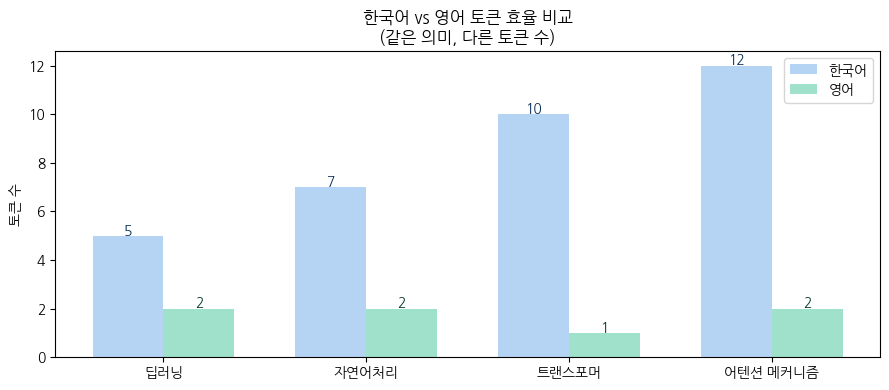

-> 한국어는 영어보다 토큰 수가 2~3배 많아 API 비용에 영향

  블록 3. 프롬프트 구체성 실험

[모호한 질문]
  질문: 연구 잘 하는 방법?
  답변: 연구를 “잘” 한다는 건 보통  
1) 좋은 문제를 고르고  
2) 효율적으로 파고들고  
3) 결과를 설득력 있게 보여주는 것  
까지를 포함합니다. 단계별로 핵심만 정리해볼게요.

---

## 1. 주제/문제 설정을 잘하는 법

1. **“재미 + 필요 + 가능” 세 가지를 동시에 보세요.**
   - 재미: 내가 진짜 궁금한가? 1~2년 붙잡고 있어...
  토큰: 입력=16 / 출력=300

[구체적 질문]
  질문: NLP 논문에서 실험 재현성을 높이기 위한 방법 3가지를 각 2문장으로 설명해줘
  답변: 1. **무작위성 통제 (Random Seed 고정)**  
   모델 초기화, 데이터 셔플, 배치 생성 등에 사용되는 난수 시드를 고정해 실험을 다시 실행했을 때 결과 변동을 최소화한다. 사용한 모든 라이브러리(PyTorch, NumPy 등)의 시드 설정 방법을 명시하고, 가능한 경우 연산 비결정성 옵션도 비활성화한다.

2. **실험 환경 및 설정의 상...
  토큰: 입력=38 / 출력=290

[역할+조건]
  질문: NLP 논문에서 실험 재현성을 높이기 위한 방법 3가지를 각 2문장으로 설명해줘
  답변: 1. **코드와 스크립트 공개**  
   모델/데이터 전처리/학습/평가 전체 파이프라인을 포함한 코드를 깃허브 등으로 공개하고, 의존 라이브러리 버전까지 명시한다. 단순 코드 스니펫이 아니라 `run.sh`, `train.py`, `eval.py` 등 end-to-end 실행 가능한 스크립트를 제공한다.

2. **실험 설정의 세부 명시**  
   랜덤...
  토큰: 입력=59 / 출력=288


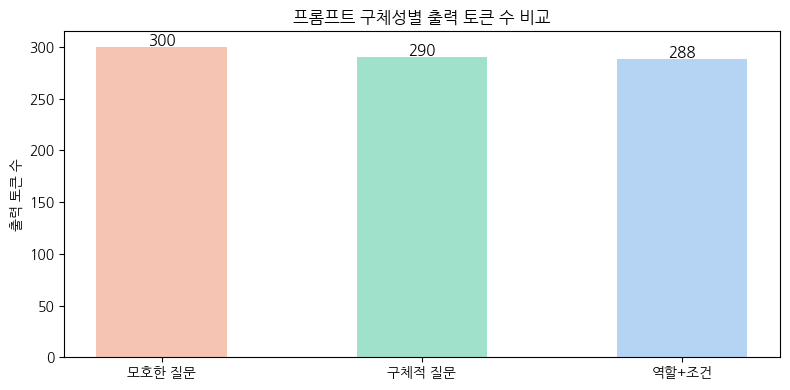


핵심 정리:
  역할   : '당신은 ... 전문가입니다' -> 응답 관점 설정
  지시   : '... 하세요' -> 수행 작업 명시
  형식   : '1) 2) 3) 순서로' -> 출력 구조 고정
  조건   : '... 이내로' -> 길이·범위 제한
  -> 다음 실습: 이 4요소를 논문 초록 구조화 추출에 적용


In [ ]:
# ============================================================
# 실습 2-2. OpenAI API 프롬프트 엔지니어링
# 목표: 4요소(역할·지시·형식·조건) 설계로 답변 품질 차이를 체감한다
# 사전 설치: pip install openai tiktoken koreanize-matplotlib
# ============================================================

import os
import tiktoken
import matplotlib.pyplot as plt
import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False

# ── API 키 설정 ──────────────────────────────────────────────
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    print("Colab Secrets에서 API 키 로드 완료")
except Exception:
    pass
# os.environ["OPENAI_API_KEY"] = "sk-..."

if not os.environ.get("OPENAI_API_KEY"):
    raise ValueError(
        "API 키가 설정되지 않았습니다.\n"
        "방법 A: 왼쪽 사이드바 열쇠 아이콘 -> 'OPENAI_API_KEY' 등록\n"
        "방법 B: os.environ['OPENAI_API_KEY'] = 'sk-...' 주석 해제"
    )

from openai import OpenAI
client = OpenAI()
print(f"API 키 확인: sk-...{os.environ['OPENAI_API_KEY'][-4:]}")


# ============================================================
# [실습 변수] 여기만 수정하여 다양한 실험 가능
# ============================================================

# 프롬프트 비교 대상 질문
# 역할 없음 vs 4요소 모두 적용 시 품질 차이를 볼 질문
QUESTION = "딥러닝 기반 자연어처리 모델의 과적합 문제를 설명해줘"

# 시스템 프롬프트: 역할(Role) 요소
SYS_ROLE = "딥러닝 전문 연구원"

# 답변 생성 온도: 사실 기반 설명이므로 낮게 유지
TEMPERATURE = 0.3

# 최대 출력 토큰 수
MAX_TOKENS = 400

# 프롬프트 구체성 비교 실험 목록
# (레이블, 시스템 프롬프트, 사용자 질문) 형태
PROMPTS_COMPARE = [
    (
        "모호한 질문",
        "",
        "연구 잘 하는 방법?"
    ),
    (
        "구체적 질문",
        "",
        "NLP 논문에서 실험 재현성을 높이기 위한 방법 3가지를 각 2문장으로 설명해줘"
    ),
    (
        "역할+조건",
        "당신은 NLP 분야 시니어 연구원입니다. 핵심만 간결하게 답하세요.",
        "NLP 논문에서 실험 재현성을 높이기 위한 방법 3가지를 각 2문장으로 설명해줘"
    ),
]

# tiktoken 토큰 계산 대상 텍스트 목록
TOKEN_SAMPLES = [
    "딥러닝",
    "자연어처리",
    "Transformer-based language model",
]

# ============================================================
# 이하 코드는 수정 불필요
# ============================================================

# ── 공통 함수 ─────────────────────────────────────────────────
# 수정된 chat 함수
def chat(system_prompt, user_prompt,
         temperature=TEMPERATURE, max_tokens=MAX_TOKENS):
    """OpenAI Chat Completions 호출 함수"""
    resp = client.chat.completions.create(
        model="gpt-5.1",  # 혹은 사용 중이신 모델 ID
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt},
        ],
        temperature=temperature,
        # 짚어드린 부분: max_tokens 대신 max_completion_tokens 사용!
        max_completion_tokens=max_tokens,
    )
    return resp.choices[0].message.content, resp.usage


def section(title):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")


# ── 블록 1: 역할 부여 유무 비교 ──────────────────────────────
section("블록 1. 역할 부여 유무 비교")

# 프롬프트 4요소 구성
# [역할] 응답자 정체, [지시] 수행 작업,
# [형식] 출력 구조, [조건] 제약 사항
sys_4elements = f"""역할: 당신은 {SYS_ROLE}입니다.
지시: 핵심 개념만 간결하게 설명하세요.
형식: 1) 정의 2) 원인 3) 해결 방법 순서로 작성하세요.
조건: 수식 없이 직관적 언어로, 3문장 이내로 각 항목을 설명하세요."""

# 역할 없음 — 4요소 미적용
ans_plain, _ = chat(
    system_prompt="",
    user_prompt=QUESTION,
)
print(f"\n[역할 없음]")
print(f"질문: {QUESTION}")
print(f"답변:\n{ans_plain[:400]}...")

# 4요소 모두 적용
ans_role, usage = chat(
    system_prompt=sys_4elements,
    user_prompt=QUESTION,
)
print(f"\n[역할+지시+형식+조건 부여]")
print(f"답변:\n{ans_role}")
print(f"\n토큰 사용량: 입력={usage.prompt_tokens} / 출력={usage.completion_tokens}")
print("-> 시스템 프롬프트에 4요소를 명시할수록 일관된 형식의 답변 생성")


# ── 블록 2: tiktoken 토큰 계산 ───────────────────────────────
section("블록 2. tiktoken 토큰 계산 (BPE 기반)")

# cl100k_base: gpt-4o-mini와 동일한 인코딩
# 실습 1-1의 BPE 토크나이저와 같은 원리
enc = tiktoken.get_encoding("cl100k_base")

print("\n텍스트별 토큰 수 (BPE 서브워드 분절 결과):")
print("-" * 55)
for text in TOKEN_SAMPLES:
    tokens = enc.encode(text)
    decoded = [enc.decode([t]) for t in tokens]
    print(f"  {text!r:40s} -> {len(tokens):3d} 토큰  {decoded}")

# 시스템 프롬프트 전체 토큰 수
sys_tokens = enc.encode(sys_4elements)
print(f"\n  시스템 프롬프트 전체 -> {len(sys_tokens)} 토큰")
print("-> 전날 BPE 실습에서 본 서브워드 분절이 토큰 수를 결정")

# 한국어 vs 영어 토큰 효율 비교 시각화
pairs = [
    ("딥러닝", "deep learning"),
    ("자연어처리", "NLP"),
    ("트랜스포머", "Transformer"),
    ("어텐션 메커니즘", "Attention mechanism"),
]
ko_counts = [len(enc.encode(ko)) for ko, _ in pairs]
en_counts = [len(enc.encode(en)) for _, en in pairs]
labels    = [ko for ko, _ in pairs]

x = range(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([i - w/2 for i in x], ko_counts, w, label="한국어", color="#B5D4F4")
ax.bar([i + w/2 for i in x], en_counts, w, label="영어",   color="#9FE1CB")
for i, (k, e) in enumerate(zip(ko_counts, en_counts)):
    ax.text(i - w/2, k + 0.05, str(k), ha='center', fontsize=10, color="#042C53")
    ax.text(i + w/2, e + 0.05, str(e), ha='center', fontsize=10, color="#04342C")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("토큰 수")
ax.set_title("한국어 vs 영어 토큰 효율 비교\n(같은 의미, 다른 토큰 수)")
ax.legend()
plt.tight_layout()
plt.savefig("token_efficiency.png", dpi=150, bbox_inches='tight')
plt.show()
print("-> 한국어는 영어보다 토큰 수가 2~3배 많아 API 비용에 영향")


# ── 블록 3: 프롬프트 구체성 실험 ─────────────────────────────
section("블록 3. 프롬프트 구체성 실험")

results = []
for label, sys_p, usr_p in PROMPTS_COMPARE:
    ans, usage_c = chat(sys_p, usr_p, max_tokens=300)
    results.append((label, usr_p, ans, usage_c))
    print(f"\n[{label}]")
    print(f"  질문: {usr_p[:70]}")
    print(f"  답변: {ans[:200]}...")
    print(f"  토큰: 입력={usage_c.prompt_tokens} / 출력={usage_c.completion_tokens}")

# 답변 길이 비교 시각화 (출력 토큰 수)
fig, ax = plt.subplots(figsize=(8, 4))
labels_c  = [r[0] for r in results]
out_toks  = [r[3].completion_tokens for r in results]
colors_c  = ["#F5C4B3", "#9FE1CB", "#B5D4F4"]
bars = ax.bar(labels_c, out_toks, color=colors_c, edgecolor="none", width=0.5)
for bar, v in zip(bars, out_toks):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, str(v),
            ha='center', fontsize=11)
ax.set_ylabel("출력 토큰 수")
ax.set_title("프롬프트 구체성별 출력 토큰 수 비교")
plt.tight_layout()
plt.savefig("prompt_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n핵심 정리:")
print("  역할   : '당신은 ... 전문가입니다' -> 응답 관점 설정")
print("  지시   : '... 하세요' -> 수행 작업 명시")
print("  형식   : '1) 2) 3) 순서로' -> 출력 구조 고정")
print("  조건   : '... 이내로' -> 길이·범위 제한")
print("  -> 다음 실습: 이 4요소를 논문 초록 구조화 추출에 적용")

In [ ]:
# 현재 사용 가능한 모든 모델 리스트 가져오기
models_list = client.models.list()

# 모델 ID만 추출해서 출력
for model in models_list.data:
    print(model.id)

text-embedding-ada-002
whisper-1
gpt-3.5-turbo
tts-1
gpt-3.5-turbo-16k
gpt-4-0613
gpt-4
davinci-002
babbage-002
gpt-3.5-turbo-instruct
gpt-3.5-turbo-instruct-0914
gpt-3.5-turbo-1106
tts-1-hd
tts-1-1106
tts-1-hd-1106
text-embedding-3-small
text-embedding-3-large
gpt-3.5-turbo-0125
gpt-4-turbo
gpt-4-turbo-2024-04-09
gpt-4o
gpt-4o-2024-05-13
gpt-4o-mini-2024-07-18
gpt-4o-mini
gpt-4o-2024-08-06
omni-moderation-latest
omni-moderation-2024-09-26
o1-2024-12-17
o1
o3-mini
o3-mini-2025-01-31
gpt-4o-2024-11-20
gpt-4o-mini-search-preview-2025-03-11
gpt-4o-mini-search-preview
gpt-4o-transcribe
gpt-4o-mini-transcribe
o1-pro-2025-03-19
o1-pro
gpt-4o-mini-tts
o3-2025-04-16
o4-mini-2025-04-16
o3
o4-mini
gpt-4.1-2025-04-14
gpt-4.1
gpt-4.1-mini-2025-04-14
gpt-4.1-mini
gpt-4.1-nano-2025-04-14
gpt-4.1-nano
gpt-image-1
o4-mini-deep-research
gpt-4o-transcribe-diarize
o4-mini-deep-research-2025-06-26
gpt-5-chat-latest
gpt-5-2025-08-07
gpt-5
gpt-5-mini-2025-08-07
gpt-5-mini
gpt-5-nano-2025-08-07
gpt-5-nano
gp